In [1]:
import pandas as pd
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

# 1. Chargement des données d'entraînement
train_df = pd.read_csv('../../data/farms_train.csv')
test_df = pd.read_csv('../../data/farms_test.csv')


In [ ]:

X_train = train_df.drop('DIFF', axis=1)
y_train = train_df['DIFF']
X_test = test_df.copy()

for id_col in ['ID', 'Id', 'id']:
    if id_col in X_test.columns:
        X_test = X_test.drop(columns=[id_col])

X_test = X_test[X_train.columns]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Entraînement avec les hyperparamètres optimaux (C=2.0236, noyau linéaire)
modele_optimal = SVC(kernel='linear', C=2.0236, random_state=42)
modele_optimal.fit(X_train_scaled, y_train)

predictions = modele_optimal.predict(X_test_scaled)

submission = pd.DataFrame({
    'ID': range(1, len(predictions) + 1),
    'DIFF': predictions
})

submission.to_csv('submission_linear_all_vars.csv', index=False)

print(f"Prédictions terminées ({len(submission)} lignes).")
print(f"Répartition prédite :\n{submission['DIFF'].value_counts(normalize=True).round(4) * 100}%")
print("\nAperçu des premières lignes :")
print(submission.head())

Prédictions terminées (120 lignes).
Répartition prédite :
DIFF
1    57.5
0    42.5
Name: proportion, dtype: float64%

Aperçu des premières lignes :
   ID  DIFF
0   1     0
1   2     1
2   3     1
3   4     1
4   5     1


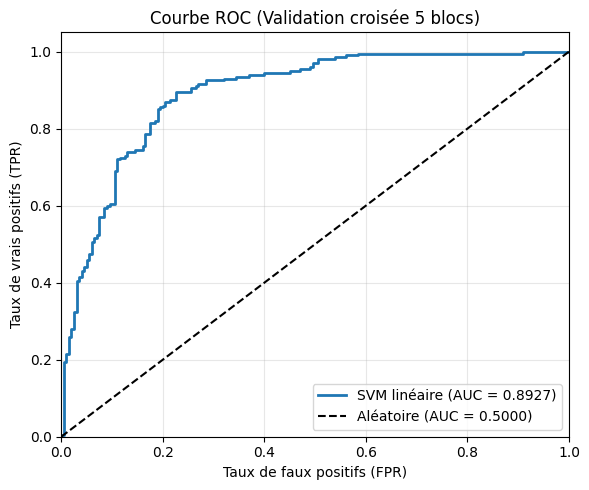

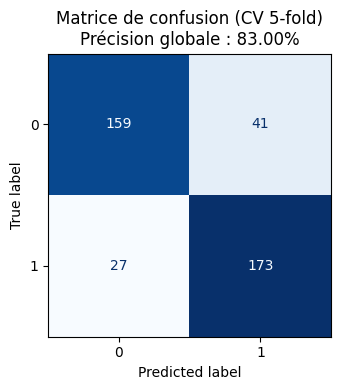

Évaluation terminée — AUC : 0.8927
Fichiers sauvegardés : 'courbe_roc_svm.png' et 'matrice_confusion_svm.png'


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

train_df = pd.read_csv('../../data/farms_train.csv')
X = train_df.drop('DIFF', axis=1)
y = train_df['DIFF']

# 2. Normalisation
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Modèle SVM optimal (linéaire, C=2.0236, toutes variables)
modele = SVC(kernel='linear', C=2.0236, random_state=42)

# 5-Fold
y_scores = cross_val_predict(modele, X_scaled, y, cv=5, method='decision_function')
auc = roc_auc_score(y, y_scores)
fpr, tpr, _ = roc_curve(y, y_scores)

y_pred = cross_val_predict(modele, X_scaled, y, cv=5)
cm = confusion_matrix(y, y_pred)

# 5.ROC
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='#1f77b4', lw=2, label=f'SVM linéaire (AUC = {auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Aléatoire (AUC = 0.5000)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taux de faux positifs (FPR)')
plt.ylabel('Taux de vrais positifs (TPR)')
plt.title('Courbe ROC (Validation croisée 5 blocs)')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('courbe_roc_svm.png', dpi=300, bbox_inches='tight')
plt.show()

# Matrice de coufusion
fig, ax = plt.subplots(figsize=(5, 4))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f'Matrice de confusion (CV 5-fold)\nPrécision globale : {(cm.diagonal().sum() / cm.sum()) * 100:.2f}%')
plt.tight_layout()
plt.savefig('matrice_confusion_svm.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Évaluation terminée — AUC : {auc:.4f}")
print(f"Fichiers sauvegardés : 'courbe_roc_svm.png' et 'matrice_confusion_svm.png'")